# **PREPARATION**

## **Library**

In [2]:
# !pip install pandas numpy matplotlib seaborn plotly folium streamlit shapely geopandas missingno --quiet

In [27]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')
import os

## **Dataset**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Tentukan path (sesuaikan dengan lokasi file Anda)
base_path = '/content/drive/MyDrive/Spasio TA/Dataset/'

# Load CSV biasa (pandas akan membaca otomatis)
df_garis = pd.read_csv(base_path + 'Garis Kemiskinan Perkapita.csv')
df_jumlah = pd.read_csv(base_path + 'Jumlah Penduduk Miskin.csv')
df_persen = pd.read_csv(base_path + 'Persentase Penduduk Miskin.csv')
df_tpt = pd.read_csv(base_path + 'Persentase Tingkat Pengangguran Terbuka.csv')

In [6]:
datasets = {
    'Garis Kemiskinan': df_garis,
    'Jumlah Penduduk Miskin': df_jumlah,
    'Persentase Penduduk Miskin': df_persen,
    'TPT': df_tpt
}

# Lihat bentuk data
for name, df in datasets.items():
    print(f"\n{name}")
    print(f"   Shape: {df.shape}")
    print(f"   Sample 5 baris:")
    print(df.head())
    print("-" * 40)
    print("")


Garis Kemiskinan
   Shape: (36, 20)
   Sample 5 baris:
                    Unnamed: 0    2007    2008    2009    2010    2011  \
0    3300 PROVINSI JAWA TENGAH  154111  181877  201651  217327  217440   
1       3301 Kabupaten Cilacap  141840  161646  191167  206714  224530   
2      3302 Kabupaten Banyumas  164111  189735  208583  225546  249807   
3   3303 Kabupaten Purbalingga  148735  164046  194529  210349  230461   
4  3304 Kabupaten Banjarnegara  146531  158702  160345  173385  192303   

     2012    2013    2014    2015    2016    2017    2018    2019    2020  \
0  233769  261881  281570  297851  317348  333224  350875  369385  395407   
1  240025  256615  265714  273828  292525  307041  320106  337572  351735   
2  271800  295742  309106  320585  344514  357748  366442  385140  406250   
3  247508  265262  275022  283366  301862  313343  324735  355702  375199   
4  205369  221056  229718  236399  252328  264387  278210  301792  318334   

     2021    2022    2023    2024   

# **PREPROCESSING DATA**

## **Non Multi Year**

In [7]:
# Fungsi sederhana untuk mengubah dari wide ke long format
def ubah_ke_long(df, nama_variable):
    # Kolom pertama berisi nama wilayah, sisanya adalah tahun
    tahun = [col for col in df.columns if col != df.columns[0]]

    # Ubah ke format panjang
    df_long = pd.melt(
        df,
        id_vars=[df.columns[0]],
        value_vars=tahun,
        var_name='tahun',
        value_name=nama_variable
    )

    # Rename kolom wilayah
    df_long.rename(columns={df.columns[0]: 'wilayah'}, inplace=True)

    # Konversi tahun ke integer
    df_long['tahun'] = df_long['tahun'].astype(int)

    return df_long

# Ubah semua dataset
df_garis_long = ubah_ke_long(df_garis, 'garis_kemiskinan')
df_jumlah_long = ubah_ke_long(df_jumlah, 'jumlah_miskin')
df_persen_long = ubah_ke_long(df_persen, 'persen_miskin')
df_tpt_long = ubah_ke_long(df_tpt, 'tpt')

print("Data berhasil diubah ke format panjang")
print(f"Hasil data setelah diubah:")
print(df_garis_long.head())

Data berhasil diubah ke format panjang
Hasil data setelah diubah:
                       wilayah  tahun  garis_kemiskinan
0    3300 PROVINSI JAWA TENGAH   2007            154111
1       3301 Kabupaten Cilacap   2007            141840
2      3302 Kabupaten Banyumas   2007            164111
3   3303 Kabupaten Purbalingga   2007            148735
4  3304 Kabupaten Banjarnegara   2007            146531


In [8]:
# Pisahkan kode dan nama kabupaten
def ekstrak_kode_nama(wilayah):
    wilayah = str(wilayah).strip()
    if wilayah[:4].isdigit():
        kode = wilayah[:4]
        nama = wilayah[4:].strip()
    else:
        kode = None
        nama = wilayah
    return kode, nama

# Terapkan ke semua dataset
for df in [df_garis_long, df_jumlah_long, df_persen_long, df_tpt_long]:
    df[['kode', 'kabupaten']] = df['wilayah'].apply(lambda x: pd.Series(ekstrak_kode_nama(x)))

print("Kode dan nama kabupaten berhasil dipisah")
print(df_garis_long[['wilayah', 'kode', 'kabupaten']].head())

Kode dan nama kabupaten berhasil dipisah
                       wilayah  kode               kabupaten
0    3300 PROVINSI JAWA TENGAH  3300    PROVINSI JAWA TENGAH
1       3301 Kabupaten Cilacap  3301       Kabupaten Cilacap
2      3302 Kabupaten Banyumas  3302      Kabupaten Banyumas
3   3303 Kabupaten Purbalingga  3303   Kabupaten Purbalingga
4  3304 Kabupaten Banjarnegara  3304  Kabupaten Banjarnegara


In [9]:
# Data provinsi (kode 3300)
provinsi_garis = df_garis_long[df_garis_long['kode'] == '3300'].copy()
provinsi_jumlah = df_jumlah_long[df_jumlah_long['kode'] == '3300'].copy()
provinsi_persen = df_persen_long[df_persen_long['kode'] == '3300'].copy()
provinsi_tpt = df_tpt_long[df_tpt_long['kode'] == '3300'].copy()

# Data kabupaten dan kota (kode bukan 3300)
kab_garis = df_garis_long[df_garis_long['kode'] != '3300'].copy()
kab_jumlah = df_jumlah_long[df_jumlah_long['kode'] != '3300'].copy()
kab_persen = df_persen_long[df_persen_long['kode'] != '3300'].copy()
kab_tpt = df_tpt_long[df_tpt_long['kode'] != '3300'].copy()

print(f"Data Provinsi: {len(provinsi_garis)} baris")
print(f"Data Kabupaten dan Kota: {len(kab_garis)} baris")

Data Provinsi: 19 baris
Data Kabupaten dan Kota: 665 baris


In [10]:
# Mulai dengan data persen kemiskinan
df_master = kab_persen[['kode', 'kabupaten', 'tahun', 'persen_miskin']].copy()

# Gabungkan dengan data lainnya
df_master = df_master.merge(kab_garis[['kode', 'tahun', 'garis_kemiskinan']], on=['kode', 'tahun'], how='left')
df_master = df_master.merge(kab_jumlah[['kode', 'tahun', 'jumlah_miskin']], on=['kode', 'tahun'], how='left')
df_master = df_master.merge(kab_tpt[['kode', 'tahun', 'tpt']], on=['kode', 'tahun'], how='left')

# Lihat hasil
print("Data master berhasil digabungkan")
print(f"Shape: {df_master.shape}")
print(f"\n5 baris pertama:")
print(df_master.head(10))

Data master berhasil digabungkan
Shape: (665, 7)

5 baris pertama:
   kode               kabupaten  tahun  persen_miskin  garis_kemiskinan  \
0  3301       Kabupaten Cilacap   2007          22.59            141840   
1  3302      Kabupaten Banyumas   2007          22.46            164111   
2  3303   Kabupaten Purbalingga   2007          30.24            148735   
3  3304  Kabupaten Banjarnegara   2007          27.18            146531   
4  3305       Kabupaten Kebumen   2007          30.25            162301   
5  3306     Kabupaten Purworejo   2007          20.49            148607   
6  3307      Kabupaten Wonosobo   2007          32.29            144809   
7  3308      Kabupaten Magelang   2007          17.37            126638   
8  3309      Kabupaten Boyolali   2007          18.06            152169   
9  3310        Kabupaten Klaten   2007          22.27            203205   

   jumlah_miskin    tpt  
0          363.6  11.48  
1          333.0   8.07  
2          246.3   7.56  
3  

## **Missing Value**

In [11]:
# Cek missing values
print("Missing values per kolom:")
print(df_master.isnull().sum())

Missing values per kolom:
kode                0
kabupaten           0
tahun               0
persen_miskin       0
garis_kemiskinan    0
jumlah_miskin       0
tpt                 0
dtype: int64


## **Statistik Dataset**

In [12]:
# Statistik Deskriptif
kolom_numerik = ['garis_kemiskinan', 'jumlah_miskin', 'persen_miskin', 'tpt']

print("STATISTIK DESKRIPTIF")
print(df_master[kolom_numerik].describe())

STATISTIK DESKRIPTIF
       garis_kemiskinan  jumlah_miskin  persen_miskin         tpt
count        665.000000     665.000000     665.000000  665.000000
mean      333562.221053     130.833789      13.091023    5.769519
std       117838.167801      79.671691       5.136517    2.228884
min       126638.000000       6.930000       3.800000    1.500000
25%       240551.000000      81.280000       9.350000    4.230000
50%       320585.000000     116.500000      12.360000    5.420000
75%       414901.000000     168.700000      16.170000    6.990000
max       709785.000000     492.200000      32.290000   15.740000


## **DF MASTER SAVE**

In [30]:
output_path = '/content/drive/MyDrive/Spasio TA/Output/'
os.makedirs(output_path, exist_ok=True)

# Simpan df_master ke CSV
df_master.to_csv(output_path + 'df_master.csv', index=False)
print(f"df_master.csv berhasil disimpan di: {output_path}df_master.csv")

df_master.csv berhasil disimpan di: /content/drive/MyDrive/Spasio TA/Output/df_master.csv


## **VISUALISASI**

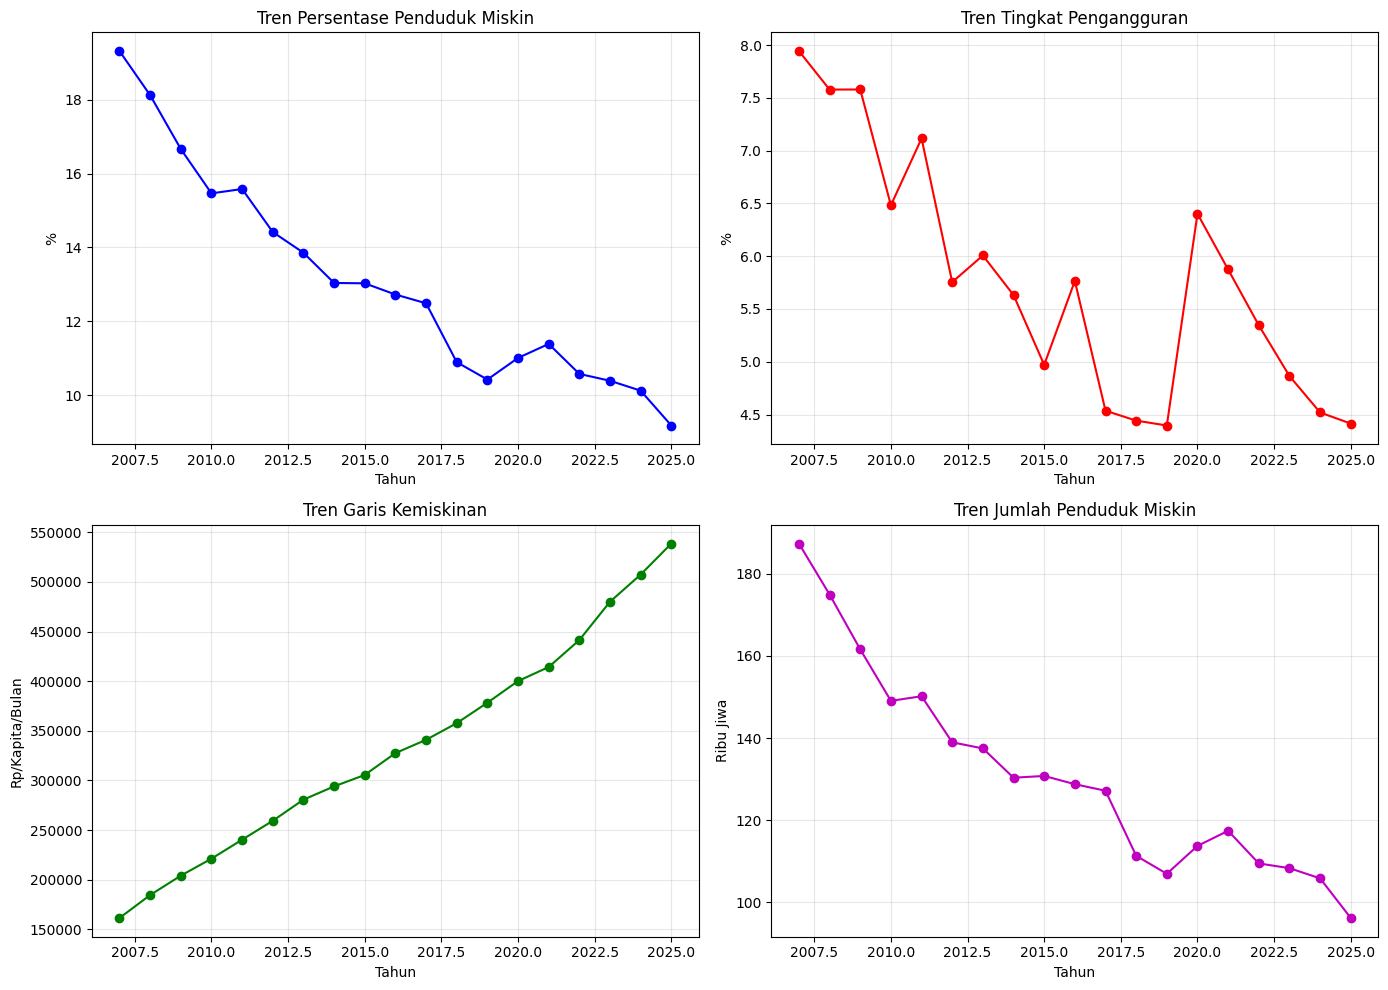

In [13]:
# Tren Rata-rata per Tahun
tren_tahunan = df_master.groupby('tahun')[kolom_numerik].mean().reset_index()

# Plot tren
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(tren_tahunan['tahun'], tren_tahunan['persen_miskin'], 'b-o')
axes[0,0].set_title('Tren Persentase Penduduk Miskin')
axes[0,0].set_ylabel('%')

axes[0,1].plot(tren_tahunan['tahun'], tren_tahunan['tpt'], 'r-o')
axes[0,1].set_title('Tren Tingkat Pengangguran')
axes[0,1].set_ylabel('%')

axes[1,0].plot(tren_tahunan['tahun'], tren_tahunan['garis_kemiskinan'], 'g-o')
axes[1,0].set_title('Tren Garis Kemiskinan')
axes[1,0].set_ylabel('Rp/Kapita/Bulan')

axes[1,1].plot(tren_tahunan['tahun'], tren_tahunan['jumlah_miskin'], 'm-o')
axes[1,1].set_title('Tren Jumlah Penduduk Miskin')
axes[1,1].set_ylabel('Ribu Jiwa')

for ax in axes.flat:
    ax.set_xlabel('Tahun')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

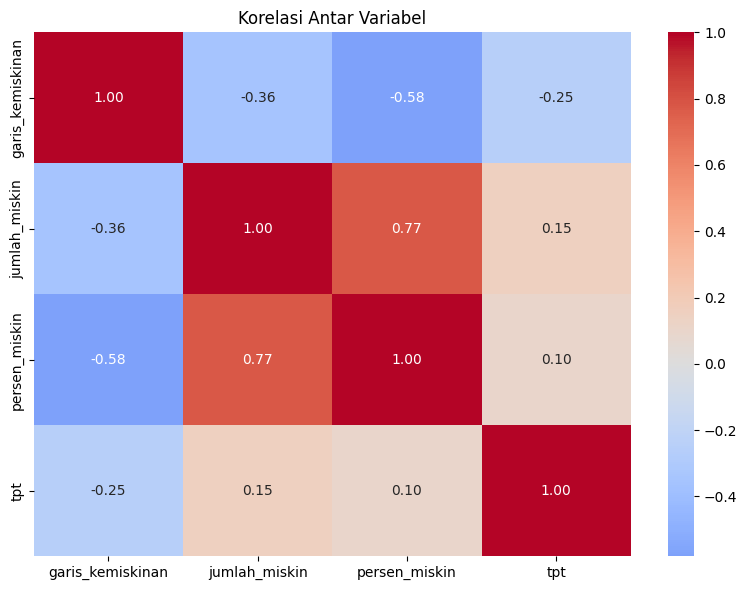

In [14]:
# Korelasi antar variabel
plt.figure(figsize=(8, 6))
corr = df_master[kolom_numerik].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Korelasi Antar Variabel')
plt.tight_layout()
plt.show()

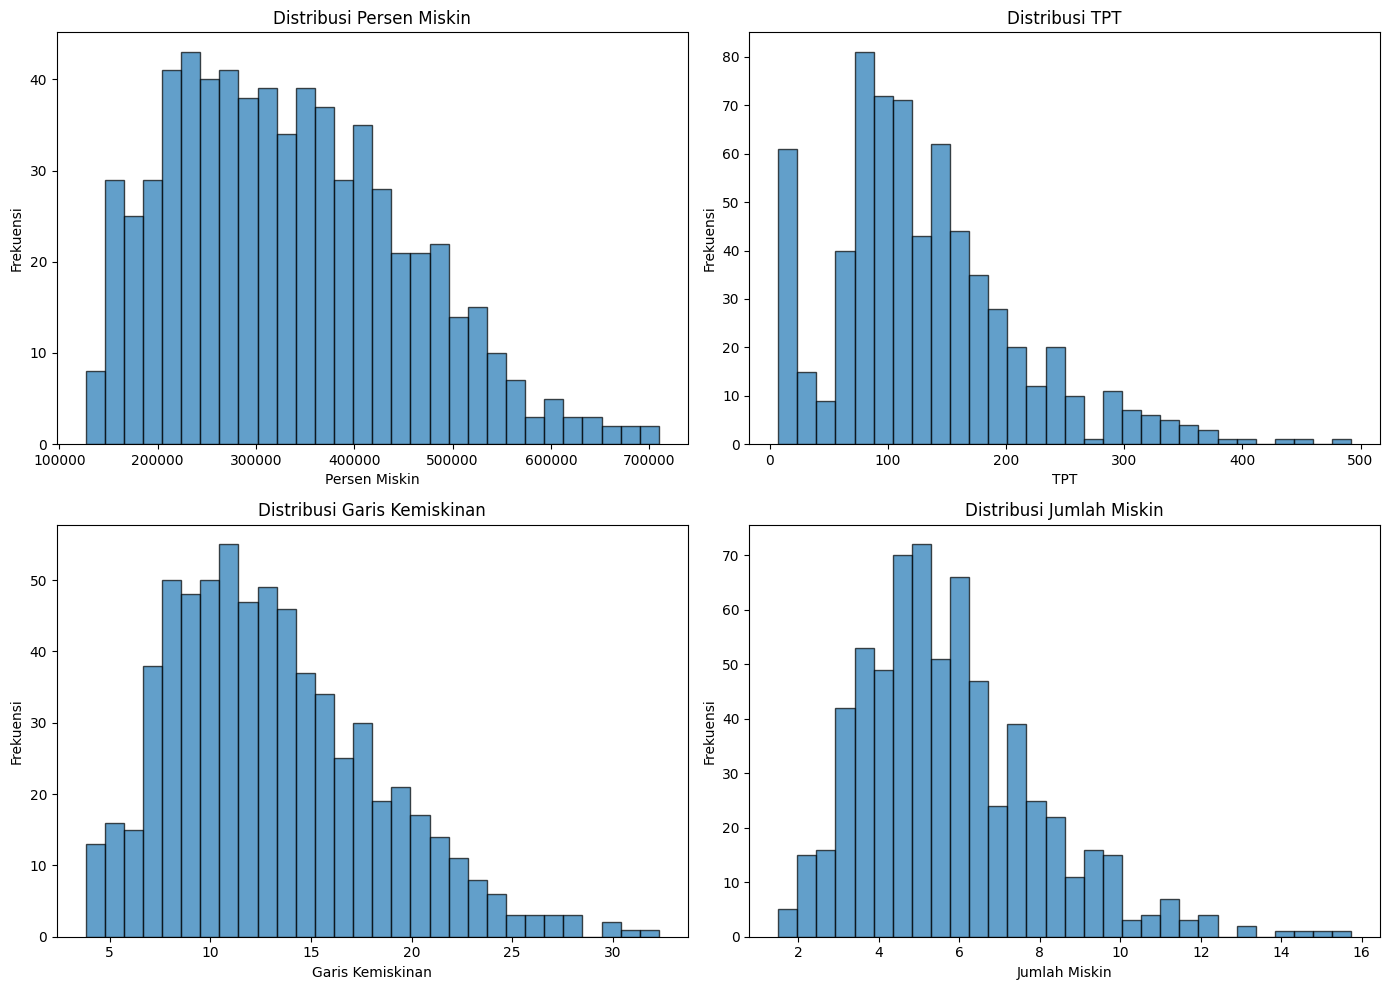

In [15]:
# Distribusi data (histogram)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, kol, title in zip(axes.flat, kolom_numerik,
                          ['Persen Miskin', 'TPT', 'Garis Kemiskinan', 'Jumlah Miskin']):
    ax.hist(df_master[kol].dropna(), bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribusi {title}')
    ax.set_xlabel(title)
    ax.set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()

In [16]:
tahun_terbaru = df_master['tahun'].max()
data_terbaru = df_master[df_master['tahun'] == tahun_terbaru].sort_values('persen_miskin', ascending=False)

print(f"DATA TAHUN {tahun_terbaru}")
print("\n5 Kabupaten dengan Persentase Kemiskinan TERTINGGI:")
print(data_terbaru[['kabupaten', 'persen_miskin', 'tpt']].head(5).to_string(index=False))

print("\n5 Kabupaten dengan Persentase Kemiskinan TERENDAH:")
print(data_terbaru[['kabupaten', 'persen_miskin', 'tpt']].tail(5).to_string(index=False))

DATA TAHUN 2025

5 Kabupaten dengan Persentase Kemiskinan TERTINGGI:
             kabupaten  persen_miskin  tpt
      Kabupaten Brebes          14.15 8.07
     Kabupaten Kebumen          13.58 4.95
    Kabupaten Wonosobo          13.34 3.99
    Kabupaten Pemalang          13.32 6.61
Kabupaten Banjarnegara          13.28 5.39

5 Kabupaten dengan Persentase Kemiskinan TERENDAH:
       kabupaten  persen_miskin  tpt
 Kota Pekalongan           6.14 4.83
Kabupaten Jepara           5.79 3.30
   Kota Magelang           5.68 4.31
   Kota Salatiga           4.20 3.67
   Kota Semarang           3.80 5.65


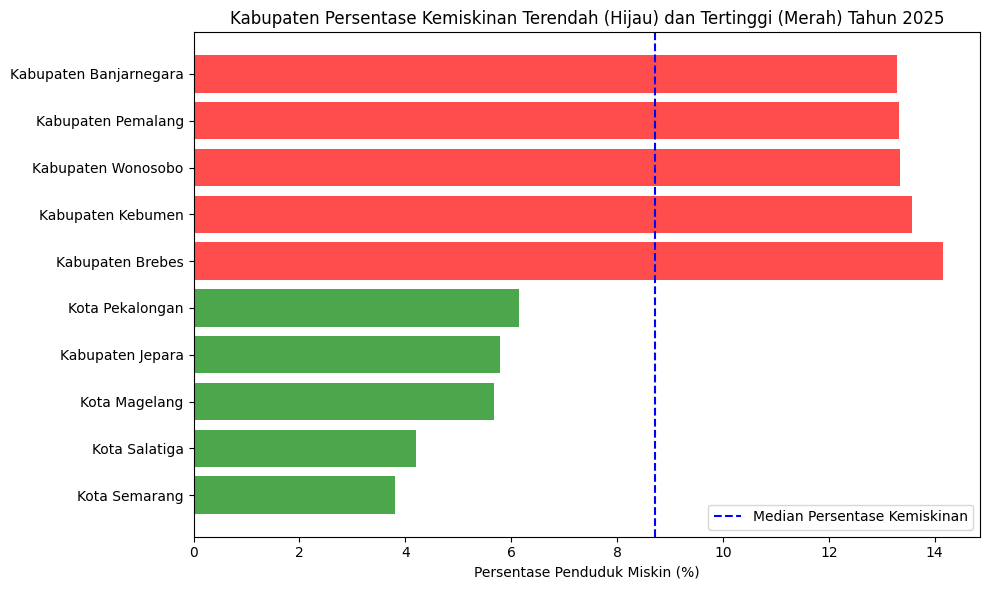

In [17]:
# Visualisasi
fig, ax = plt.subplots(figsize=(10, 6))
top5 = data_terbaru.head(5)
bottom5 = data_terbaru.tail(5)
kab_list = list(bottom5['kabupaten'])[::-1] + list(top5['kabupaten'])
values = list(bottom5['persen_miskin'])[::-1] + list(top5['persen_miskin'])
colors = ['green']*5 + ['red']*5

ax.barh(range(len(kab_list)), values, color=colors, alpha=0.7)
ax.set_yticks(range(len(kab_list)))
ax.set_yticklabels([k.replace('KABUPATEN ', '').replace('KOTA ', '') for k in kab_list])
ax.set_xlabel('Persentase Penduduk Miskin (%)')
ax.set_title(f'Kabupaten Persentase Kemiskinan Terendah (Hijau) dan Tertinggi (Merah) Tahun {tahun_terbaru}')
ax.axvline(data_terbaru['persen_miskin'].median(), color='blue', linestyle='--', label='Median Persentase Kemiskinan')
ax.legend()
plt.tight_layout()
plt.show()

# **GEO JSON**

In [22]:
# Load GeoJSON Provinsi Jawa Tengah
geo_path = '/content/drive/MyDrive/Spasio TA/Jawa Tengah/'
gdf = gpd.read_file(geo_path + 'Provinsi Jawa Tengah.geojson')

print(f"Shape GeoJSON: {gdf.shape}")
print("\nContoh data GeoJSON:")
print(gdf[['NAME_2', 'TYPE_2']].head())

Shape GeoJSON: (35, 13)

Contoh data GeoJSON:
         NAME_2     TYPE_2
0  Banjarnegara  Kabupaten
1      Banyumas  Kabupaten
2        Batang  Kabupaten
3         Blora  Kabupaten
4      Boyolali  Kabupaten


In [23]:
# TYPE_2 (Kabupaten atau Kota)
print("Jenis wilayah (TYPE_2):")
print(gdf['TYPE_2'].value_counts())

# NAME_2 (nama wilayah)
gdf['kabupaten'] = gdf['TYPE_2'].str.upper() + ' ' + gdf['NAME_2'].str.upper()
gdf['kabupaten'] = gdf['kabupaten'].str.strip()

print("\nContoh nama kabupaten setelah diformat:")
print(gdf[['NAME_2', 'TYPE_2', 'kabupaten']].head(5))

Jenis wilayah (TYPE_2):
TYPE_2
Kabupaten    29
Kota          6
Name: count, dtype: int64

Contoh nama kabupaten setelah diformat:
         NAME_2     TYPE_2               kabupaten
0  Banjarnegara  Kabupaten  KABUPATEN BANJARNEGARA
1      Banyumas  Kabupaten      KABUPATEN BANYUMAS
2        Batang  Kabupaten        KABUPATEN BATANG
3         Blora  Kabupaten         KABUPATEN BLORA
4      Boyolali  Kabupaten      KABUPATEN BOYOLALI


In [24]:
# Fungsi standarisasi nama dengan aturan khusus
def standarisasi_nama(nama):
    nama = str(nama).upper().strip()

    # Hapus kata KABUPATEN di depan
    if nama.startswith('KABUPATEN '):
        nama = nama.replace('KABUPATEN ', '')
    elif nama.startswith('KOTA SALATIGA'):
        nama = nama.replace('KOTA SALATIGA', 'SALATIGA')
    elif nama.startswith('KOTA SURAKARTA'):
        nama = nama.replace('KOTA SURAKARTA', 'SURAKARTA')
    return nama

# Terapkan ke data master
df_master['nama_clean'] = df_master['kabupaten'].apply(standarisasi_nama)

print("Perubahan nama:")
print("Contoh hasil standarisasi data master:")
print(sorted(df_master['nama_clean'].unique()))

# Standarisasi juga di GeoJSON
gdf['nama_clean'] = gdf['NAME_2'].str.upper().str.strip()

print("\nDaftar kabupaten di GeoJSON:")
print(sorted(gdf['nama_clean'].unique()))

Perubahan nama:
Contoh hasil standarisasi data master:
['BANJARNEGARA', 'BANYUMAS', 'BATANG', 'BLORA', 'BOYOLALI', 'BREBES', 'CILACAP', 'DEMAK', 'GROBOGAN', 'JEPARA', 'KARANGANYAR', 'KEBUMEN', 'KENDAL', 'KLATEN', 'KOTA MAGELANG', 'KOTA PEKALONGAN', 'KOTA SEMARANG', 'KOTA TEGAL', 'KUDUS', 'MAGELANG', 'PATI', 'PEKALONGAN', 'PEMALANG', 'PURBALINGGA', 'PURWOREJO', 'REMBANG', 'SALATIGA', 'SEMARANG', 'SRAGEN', 'SUKOHARJO', 'SURAKARTA', 'TEGAL', 'TEMANGGUNG', 'WONOGIRI', 'WONOSOBO']

Daftar kabupaten di GeoJSON:
['BANJARNEGARA', 'BANYUMAS', 'BATANG', 'BLORA', 'BOYOLALI', 'BREBES', 'CILACAP', 'DEMAK', 'GROBOGAN', 'JEPARA', 'KARANGANYAR', 'KEBUMEN', 'KENDAL', 'KLATEN', 'KOTA MAGELANG', 'KOTA PEKALONGAN', 'KOTA SEMARANG', 'KOTA TEGAL', 'KUDUS', 'MAGELANG', 'PATI', 'PEKALONGAN', 'PEMALANG', 'PURBALINGGA', 'PURWOREJO', 'REMBANG', 'SALATIGA', 'SEMARANG', 'SRAGEN', 'SUKOHARJO', 'SURAKARTA', 'TEGAL', 'TEMANGGUNG', 'WONOGIRI', 'WONOSOBO']


In [25]:
# Cek nama yang match dan tidak match setelah perbaikan
nama_master = set(df_master['nama_clean'].unique())
nama_geojson = set(gdf['nama_clean'].unique())

match = nama_master.intersection(nama_geojson)
tidak_match_master = nama_master - nama_geojson
tidak_match_geojson = nama_geojson - nama_master

print("VALIDASI NAMA WILAYAH (SETELAH PERBAIKAN)")
print(f"Jumlah kabupaten di data master: {len(nama_master)}")
print(f"Jumlah kabupaten di GeoJSON: {len(nama_geojson)}")
print(f"Jumlah yang match: {len(match)}")

if not tidak_match_master and not tidak_match_geojson:
    print("\nSEMUA NAMA SUDAH MATCH! Siap untuk merge.")
else:
    if tidak_match_master:
        print(f"\nNama di data master TIDAK ADA di GeoJSON: {tidak_match_master}")
    if tidak_match_geojson:
        print(f"\nNama di GeoJSON TIDAK ADA di data master: {tidak_match_geojson}")

VALIDASI NAMA WILAYAH (SETELAH PERBAIKAN)
Jumlah kabupaten di data master: 35
Jumlah kabupaten di GeoJSON: 35
Jumlah yang match: 35

SEMUA NAMA SUDAH MATCH! Siap untuk merge.


In [26]:
# Merge berdasarkan nama_clean
gdf_data = gdf.merge(df_master, on='nama_clean', how='left')

print("HASIL MERGE")
print(f"Shape GeoJSON awal: {gdf.shape}")
print(f"Shape setelah merge: {gdf_data.shape}")
print(f"Jumlah data yang berhasil di-merge: {gdf_data['tahun'].notna().sum()} baris")

# Cek distribusi tahun
print("\nDistribusi data per tahun di GeoJSON:")
tahun_counts = gdf_data.groupby('tahun').size()
print(tahun_counts)

# Cek kabupaten yang tidak memiliki data
kab_tanpa_data = gdf_data[gdf_data['tahun'].isna()]['nama_clean'].unique()
if len(kab_tanpa_data) > 0:
    print(f"\nKabupaten tanpa data: {list(kab_tanpa_data)}")
else:
    print("\nSemua kabupaten memiliki data!")

# Tampilkan contoh hasil merge
print("\nContoh hasil merge (5 baris pertama):")
print(gdf_data[['NAME_2', 'nama_clean', 'tahun', 'persen_miskin']].head(10))

HASIL MERGE
Shape GeoJSON awal: (35, 15)
Shape setelah merge: (665, 22)
Jumlah data yang berhasil di-merge: 665 baris

Distribusi data per tahun di GeoJSON:
tahun
2007    35
2008    35
2009    35
2010    35
2011    35
2012    35
2013    35
2014    35
2015    35
2016    35
2017    35
2018    35
2019    35
2020    35
2021    35
2022    35
2023    35
2024    35
2025    35
dtype: int64

Semua kabupaten memiliki data!

Contoh hasil merge (5 baris pertama):
         NAME_2    nama_clean  tahun  persen_miskin
0  Banjarnegara  BANJARNEGARA   2007          27.18
1  Banjarnegara  BANJARNEGARA   2008          23.34
2  Banjarnegara  BANJARNEGARA   2009          21.36
3  Banjarnegara  BANJARNEGARA   2010          19.17
4  Banjarnegara  BANJARNEGARA   2011          20.38
5  Banjarnegara  BANJARNEGARA   2012          18.87
6  Banjarnegara  BANJARNEGARA   2013          18.71
7  Banjarnegara  BANJARNEGARA   2014          17.77
8  Banjarnegara  BANJARNEGARA   2015          18.37
9  Banjarnegara  BANJARN

In [29]:
# Buat folder untuk output individual kabupaten
output_path = '/content/drive/MyDrive/Spasio TA/Output/'
os.makedirs(output_path, exist_ok=True)
os.makedirs(output_path + 'per_kabupaten/', exist_ok=True)

# Daftar nama clean yang ada
daftar_nama_clean = df_master['nama_clean'].unique()

print("MENYIMPAN GEOJSON PER KABUPATEN/KOTA")

success_count = 0
for nama in daftar_nama_clean:
    # Coba cari file dengan berbagai kemungkinan format
    kemungkinan_file = [
        f"{nama}.geojson",
        f"{nama.lower()}.geojson",
        f"{nama.title()}.geojson",
    ]

    # Untuk nama yang mengandung spasi (misal: KOTA MAGELANG)
    if ' ' in nama:
        nama_parts = nama.split()
        kemungkinan_file.append(f"{nama_parts[0]} {nama_parts[1].title()}.geojson")
        kemungkinan_file.append(f"{nama_parts[0].title()} {nama_parts[1].title()}.geojson")
        kemungkinan_file.append(f"{nama_parts[0]}{nama_parts[1]}.geojson")

    file_ditemukan = None
    for fn in kemungkinan_file:
        file_path = geo_path + f'Kabupaten-Kota/{fn}'
        if os.path.exists(file_path):
            file_ditemukan = file_path
            break

    if file_ditemukan:
        # Load GeoJSON individu
        gdf_kab = gpd.read_file(file_ditemukan)

        # Ambil data temporal untuk kabupaten ini
        data_kab = df_master[df_master['nama_clean'] == nama].copy()

        # Simpan data temporal sebagai CSV
        data_kab.to_csv(output_path + f'per_kabupaten/{nama}_data.csv', index=False)

        # Simpan GeoJSON individu
        gdf_kab.to_file(output_path + f'per_kabupaten/{nama}.geojson', driver='GeoJSON')

        print(f"{nama} - tersimpan")
        success_count += 1
    else:
        # Jika tidak ada file individu, export dari master GeoJSON
        gdf_kab = gdf_data[gdf_data['nama_clean'] == nama].copy()
        if len(gdf_kab) > 0:
            # Ambil geometry unik (tanpa duplikasi tahun)
            gdf_kab_unique = gdf_kab.drop_duplicates(subset='nama_clean')[['nama_clean', 'geometry']]
            gdf_kab_unique.to_file(output_path + f'per_kabupaten/{nama}.geojson', driver='GeoJSON')
            print(f"{nama} - file GeoJSON individu tidak ditemukan, menggunakan dari master")
        else:
            print(f"{nama} - gagal, tidak ada geometry")

print(f"\nBerhasil menyimpan {success_count} dari {len(daftar_nama_clean)} kabupaten")

MENYIMPAN GEOJSON PER KABUPATEN/KOTA
CILACAP - tersimpan
BANYUMAS - tersimpan
PURBALINGGA - tersimpan
BANJARNEGARA - tersimpan
KEBUMEN - tersimpan
PURWOREJO - tersimpan
WONOSOBO - tersimpan
MAGELANG - tersimpan
BOYOLALI - tersimpan
KLATEN - tersimpan
SUKOHARJO - tersimpan
WONOGIRI - tersimpan
KARANGANYAR - tersimpan
SRAGEN - tersimpan
GROBOGAN - tersimpan
BLORA - tersimpan
REMBANG - tersimpan
PATI - tersimpan
KUDUS - tersimpan
JEPARA - tersimpan
DEMAK - tersimpan
SEMARANG - tersimpan
TEMANGGUNG - tersimpan
KENDAL - tersimpan
BATANG - tersimpan
PEKALONGAN - tersimpan
PEMALANG - tersimpan
TEGAL - tersimpan
BREBES - tersimpan
KOTA MAGELANG - tersimpan
SURAKARTA - tersimpan
SALATIGA - tersimpan
KOTA SEMARANG - tersimpan
KOTA PEKALONGAN - tersimpan
KOTA TEGAL - tersimpan

Berhasil menyimpan 35 dari 35 kabupaten
